In [1]:
import pickle
import pandas as pd
import numpy as np
from collections import Counter
from torchviz import make_dot

In [2]:
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
from torch.nn import Linear, Sequential, ReLU, BatchNorm1d
from torch_geometric.nn import GINConv, global_add_pool, global_mean_pool
import torch.optim as optim
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [3]:
import random # to undersample trees

In [4]:
# Fix the random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [5]:
# check that SU** matches in .pkl and _trees!
with open('wolfGraphSUVL.pkl','rb') as q:
    dataq = pickle.load(q)
    SU_trees = dataq['balanced_SUVL']
    wolfGraph = dataq['wolfGraph']
print("loaded!")

loaded!


In [6]:
# updated with new variables 
def tree_to_pyg(tree_graph, label):
    """ convert networkx tree to pyg data object ..with all new features"""

    # Node features: [ # elev, is_source, is_pit, 
    #                 max_vel, mean_vel, std_vel, mean_erosive, max_erosive, tidal_range,
    #                 total_inflow, mean_inflow, max_inflow]
    node_features = []
    node_mapping = {old_idx: new_idx for new_idx, old_idx in enumerate(tree_graph.nodes())}

    for node in tree_graph.nodes():
        feat = [
            tree_graph.nodes[node]['elev'],
            tree_graph.nodes[node]['slope'],
            tree_graph.nodes[node]['curve'],
            #1.0 if tree_graph.nodes[node].get('is_source',False) else 0.0, 
            #1.0 if tree_graph.nodes[node].get('is_source',False) else 0.0,
            tree_graph.nodes[node].get('max_vel', 0.0),
            #tree_graph.nodes[node].get('mean_vel', 0.0),
            tree_graph.nodes[node].get('tidal_range', 0.0),
            tree_graph.nodes[node].get('std_vel', 0.0),
            #tree_graph.nodes[node].get('mean_erosive_power', 0.0),
            tree_graph.nodes[node].get('max_erosive_power', 0.0),
            #tree_graph.nodes[node].get('total_inflow', 0.0),
            #tree_graph.nodes[node].get('mean_inflow', 0.0),
            #tree_graph.nodes[node].get('max_inflow', 0.0)
        ]
        node_features.append(feat)

    x = torch.tensor(node_features, dtype=torch.float)

    # edge indices and weights
    edge_index = []
    edge_weight = []

    for u, v in tree_graph.edges():
        edge_index.append([node_mapping[u], node_mapping[v]])
        edge_weight.append(tree_graph.edges[u, v]['weight'])

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_weight, dtype=torch.float).view(-1,1)

    # label
    y = torch.tensor([label], dtype=torch.long)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

In [7]:
# attempt 17 : S + U with only "natural" bluffs

label_map = {'S': 0, 'U': 1}  # Binary classification

# Rebuild dataset
pyg_dataset = []
for pit_idx, tree in SU_trees.items():
    stability = wolfGraph.nodes[pit_idx]['stability']
    label = label_map[stability]
    pyg_data = tree_to_pyg(tree, label)
    pyg_dataset.append(pyg_data)

In [8]:
# check label distribution (again!)
labels = [data.y.item() for data in pyg_dataset]
print("\nlabel distribution:")
for name, code in label_map.items():
    count = labels.count(code)
    print(f" {name} ({code}): {count}")


label distribution:
 S (0): 282
 U (1): 282


In [9]:
# Use stratified split
from sklearn.model_selection import train_test_split
train_idx, test_idx = train_test_split(
    range(len(pyg_dataset)), 
    test_size=0.1, 
    random_state=42,
    stratify=[d.y.item() for d in pyg_dataset]
)

# Use Subset to create the actual datasets
from torch.utils.data import Subset

train_data = Subset(pyg_dataset, train_idx)
test_data = Subset(pyg_dataset, test_idx)

# Now create loaders as before
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False)

print(f"\nTrain: {len(train_data)}, Test: {len(test_data)}")


Train: 507, Test: 57


# 2. train/test split (80/20)
train_data, test_data = train_test_split(
    pyg_dataset,
    test_size = 0.2,
    random_state = 42,
    stratify=labels # keep class balance in both splits
)

print(f"train: {len(train_data)}, test: {len(test_data)}")

# 3. dataloaders
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False)



In [10]:
# quick batch check
for batch in train_loader:
    print(f"batch: {batch}")
    print(f"nodes: {batch.num_nodes}, edges: {batch.num_edges}")
    print(f"labels: {batch.y}")
    break
    

batch: DataBatch(x=[3016, 7], edge_index=[2, 3000], edge_attr=[3000, 1], y=[16], batch=[3016], ptr=[17])
nodes: 3016, edges: 3000
labels: tensor([1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1])


In [11]:
# Quick data check
print(f"Dataset size: {len(pyg_dataset)}")
print(f"Train size: {len(train_data)}")
print(f"Test size: {len(test_data)}")

# Check a sample
sample = pyg_dataset[0]
print(f"Sample features shape: {sample.x.shape}")
print(f"Sample has {sample.num_nodes} nodes")
print(f"Label: {sample.y.item()}")

Dataset size: 564
Train size: 507
Test size: 57
Sample features shape: torch.Size([67, 7])
Sample has 67 nodes
Label: 0


In [12]:
# new attempt with GIN

class TreeGIN(torch.nn.Module):
    def __init__(self, num_node_features, hidden_dim=64, num_classes=2):
        super(TreeGIN, self).__init__()

        # GIN layers - each has MLP inside
        self.conv1 = GINConv(
            Sequential(
                Linear(num_node_features, hidden_dim),
                BatchNorm1d(hidden_dim),
                ReLU(),
                Linear(hidden_dim, hidden_dim),
                ReLU()
            )
        )

        self.conv2 = GINConv(
            Sequential(
                Linear(hidden_dim, hidden_dim),
                BatchNorm1d(hidden_dim),
                ReLU(),
                Linear(hidden_dim, hidden_dim),
                ReLU()
            )
        )

        self.conv3 = GINConv(
            Sequential(
                Linear(hidden_dim, hidden_dim),
                BatchNorm1d(hidden_dim),
                ReLU(),
                Linear(hidden_dim, hidden_dim),
                ReLU()
            )
        )

        # classification head
        self.fc1 = Linear(hidden_dim, hidden_dim // 2)
        self.fc2 = Linear(hidden_dim // 2, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # GIN convolutions
        x = self.conv1(x, edge_index)
        x = F.dropout(x, p=0.2, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.dropout(x, p=0.2, training=self.training)

        x = self.conv3(x, edge_index)

        # global pooling (try mean and sum)
        x = global_mean_pool(x, batch)

        # classify
        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.fc2(x)

        return F.log_softmax(x, dim=1)

In [13]:
# setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [14]:
# initialize mddel
# reinitialize model every time
num_features = 7 # set to chosen number of features
model = TreeGIN(num_node_features=num_features, hidden_dim=64, num_classes=2).to(device) # 4->3->2 classes!

In [15]:
print(model)
print(f"total parameters: {sum(p.numel() for p in model.parameters())}")

TreeGIN(
  (conv1): GINConv(nn=Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
  ))
  (conv2): GINConv(nn=Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
  ))
  (conv3): GINConv(nn=Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
  ))
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=2, bias=True)
)
total parameters: 23842


In [16]:
# criterion = torch.nn.NLLLoss() # neg. log-likelihood (pairs w. log_softmax)
# opt: use weighted loss
optimizer = optim.Adam(model.parameters(), lr=0.01) #consider reducing 
criterion = torch.nn.NLLLoss()
print(f"Criterion using weights: {criterion.weight is not None}")

Criterion using weights: False


In [17]:
# training function
def train(loader):
    model.train()
    total_loss = 0
    correct = 0

    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()

        out = model(data)
        loss = criterion(out, data.y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * data.num_graphs
        pred = out.argmax(dim=1)
        correct += (pred == data.y).sum().item()

    return total_loss / len(loader.dataset), correct / len(loader.dataset)

In [18]:
# testing function
def test(loader):
    model.eval()
    correct = 0

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)
            pred = out.argmax(dim=1)
            correct += (pred == data.y).sum().item()

    return correct / len(loader.dataset)

In [19]:
# training loop w/ early stopping

best_test_acc = 0
best_model = None
checkpoint = None
patience = 15
no_improve_count = 0
max_epochs = 300
train_losses = []
train_accs = []
test_accs = []

for epoch in range(max_epochs):
    train_loss, train_acc = train(train_loader)
    test_acc = test(test_loader)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if epoch % 10 == 0:
        print(f'epoch {epoch:03d}, loss: {train_loss:.4f}, train acc: {train_acc:.4f}, test acc: {test_acc:.4f}')

    if test_acc > best_test_acc + 0.001:
        best_test_acc = test_acc
        no_improve_count = 0
        best_model = model.state_dict().copy()
        best_epoch = epoch
        print(f"✓ Epoch {epoch}: New best: {test_acc:.4f} Train: {train_acc:.4}")
        '''
        checkpoint = {
            'epoch': epoch + 1,
            'state_dict': model.state_dict().copy(),
            'optimizer': optimizer.state_dict(),
            'loss': train_loss,
            'test_acc': test_acc
        }
        '''
        # torch.save(checkpoint, 'model_checkpoint.pth.tar')
        best_model = model.state_dict().copy()
        # torch.save(model.state_dict(), 'best_gin.pt')
    else:
        no_improve_count += 1

    if no_improve_count >= patience:
        print(f"early stopping at epoch {epoch}")
        print(f"Best was epoch {best_epoch} with {best_test_acc:.4f}")
        print(f"final test accuracy: {test_accs[-1]:.4f}")
        if best_model is not None:
            model.load_state_dict(best_model)  # ← LOAD BEST MODEL
            #optimizer.load_state_dict(['optimizer'])
            print(f"Loaded model from epoch {best_epoch}")
        break
    

epoch 000, loss: 0.6918, train acc: 0.5365, test acc: 0.7193
✓ Epoch 0: New best: 0.7193 Train: 0.5365
✓ Epoch 2: New best: 0.7895 Train: 0.6371
✓ Epoch 6: New best: 0.8070 Train: 0.6805
epoch 010, loss: 0.5988, train acc: 0.7022, test acc: 0.8070
✓ Epoch 12: New best: 0.8246 Train: 0.7061
✓ Epoch 15: New best: 0.8421 Train: 0.6607
epoch 020, loss: 0.5918, train acc: 0.6982, test acc: 0.7895
epoch 030, loss: 0.5752, train acc: 0.7318, test acc: 0.8070
early stopping at epoch 30
Best was epoch 15 with 0.8421
final test accuracy: 0.8070
Loaded model from epoch 15


# training loop
num_epochs = 300
train_losses = []
train_accs = []
test_accs = []

print(f"starting training ...\n")

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train(train_loader)
    test_acc = test(test_loader)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if epoch % 10 == 0:
        print(f'epoch {epoch:03d}, loss: {train_loss:.4f}, train acc: {train_acc:.4f}, test acc: {test_acc:.4f}')

print("\ntraining complete!")
print(f"final test accuracy: {test_accs[-1]:.4f}")

In [22]:
model.load_state_dict(best_model)
print(f"Loaded best model. Now testing...")
model.eval()
test_acc_verify = test(test_loader)  # Does this match best_test_acc?
print(f"Best saved: {best_test_acc:.4f}, Re-tested: {test_acc_verify:.4f}")

Loaded best model. Now testing...
Best saved: 0.8596, Re-tested: 0.7895


In [21]:
# results 
# using 10 features and 64 hidden layers
# early stopping patience 30, max epochs 300

# run 1: stopped at 94 epochs
# Stable: 78.3% (36/46)
# Unstable: 69.6% (32/46)

# results_stable = [78.3, ]
# results_unstable = [69.6, ]

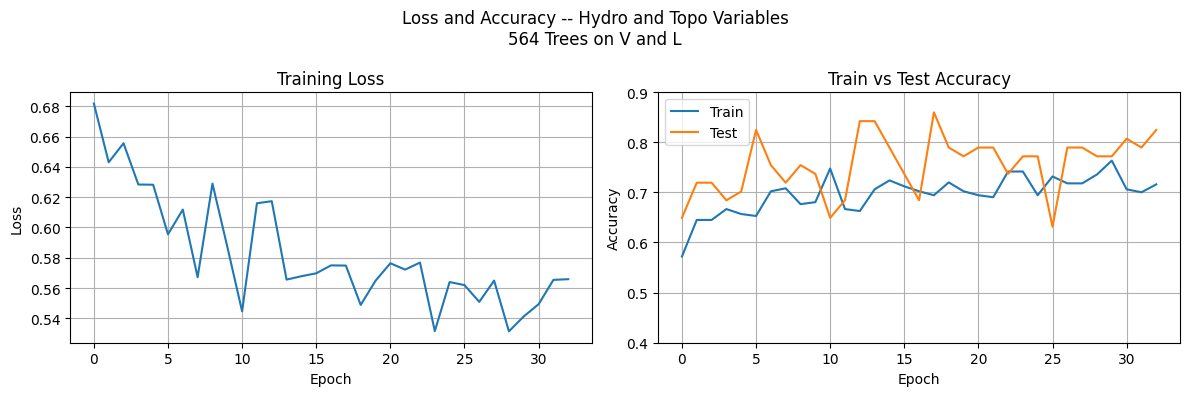

In [28]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
ax1.plot(train_losses)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
#ax1.set_ylim(0.4, 1.25)
ax1.grid(True)

# Accuracy curves
ax2.plot(train_accs, label='Train')
ax2.plot(test_accs, label='Test')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Train vs Test Accuracy')
ax2.legend()
ax2.set_ylim(0.4, 0.9)
ax2.grid(True)

fig.suptitle("Loss and Accuracy -- Hydro and Topo Variables\n564 Trees on V and L")
plt.tight_layout()
#plt.savefig("fig_564hydroTopoSUVL3_GINloss.png")
plt.show()


=== Classification Metrics (Unstable = Positive) ===
Sensitivity (Recall):  85.7%  (24/28) - Correctly identifying unstable bluffs
Specificity:           79.3%  (23/29) - Correctly identifying stable bluffs
Precision:             80.0%  (24/30) - When predicting unstable, how often correct


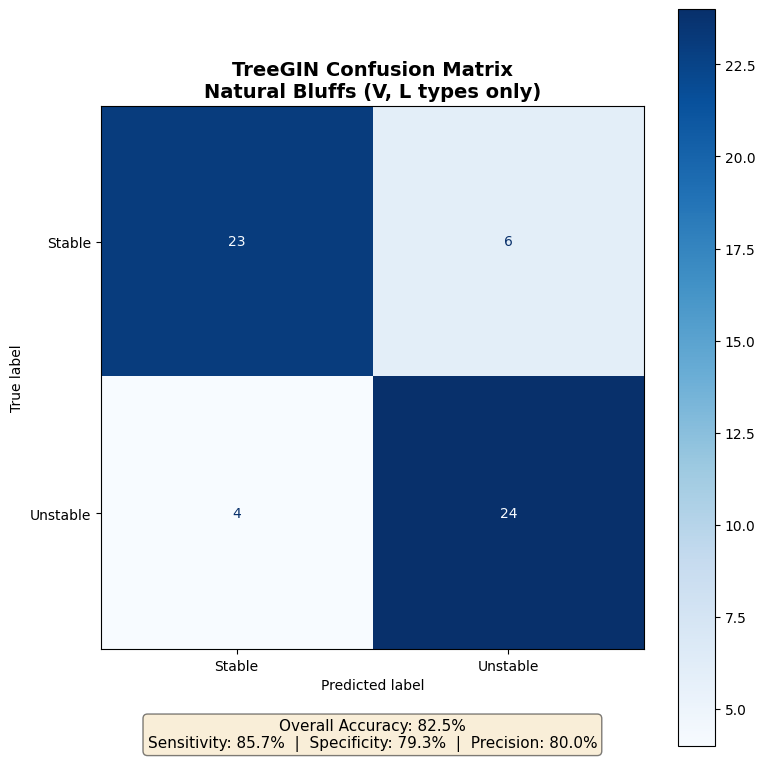


=== Per-Class Performance ===
Stable: 79.3% (23/29)
Unstable: 85.7% (24/28)


In [30]:
# Get predictions on test set
# more thorough decision matrix
model.load_state_dict(best_model)
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        out = model(data)
        pred = out.argmax(dim=1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(data.y.cpu().numpy())

# Create confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Calculate metrics (where 1 = Unstable = Positive)
# cm[0,0] = True Negative (correctly labeled Stable)
# cm[0,1] = False Positive (Stable labeled as Unstable)
# cm[1,0] = False Negative (Unstable labeled as Stable)
# cm[1,1] = True Positive (correctly labeled Unstable)

TN, FP = cm[0, 0], cm[0, 1]
FN, TP = cm[1, 0], cm[1, 1]

# Calculate metrics
sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0  # True Positive Rate / Recall for Unstable
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0  # True Negative Rate / Recall for Stable
precision = TP / (TP + FP) if (TP + FP) > 0 else 0    # Precision for Unstable

# Print metrics
print("\n=== Classification Metrics (Unstable = Positive) ===")
print(f"Sensitivity (Recall):  {sensitivity:.1%}  ({TP}/{TP+FN}) - Correctly identifying unstable bluffs")
print(f"Specificity:           {specificity:.1%}  ({TN}/{TN+FP}) - Correctly identifying stable bluffs")
print(f"Precision:             {precision:.1%}  ({TP}/{TP+FP}) - When predicting unstable, how often correct")

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Stable', 'Unstable'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('TreeGIN Confusion Matrix\nNatural Bluffs (V, L types only)', 
             fontsize=14, fontweight='bold')

# Add overall accuracy
acc = np.trace(cm) / np.sum(cm)

# Add metrics text below confusion matrix
metrics_text = (f'Overall Accuracy: {acc:.1%}\n'
                f'Sensitivity: {sensitivity:.1%}  |  '
                f'Specificity: {specificity:.1%}  |  '
                f'Precision: {precision:.1%}')

ax.text(0.5, -0.18, metrics_text, 
        transform=ax.transAxes, ha='center', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
#plt.savefig('fig_564hydroTopoSUVL3_GINcm.png', dpi=300, bbox_inches='tight')
plt.show()

# Print per-class accuracy
print("\n=== Per-Class Performance ===")
for i, label in enumerate(['Stable', 'Unstable']):
    class_acc = cm[i, i] / cm[i, :].sum() if cm[i, :].sum() > 0 else 0
    print(f"{label}: {class_acc:.1%} ({cm[i, i]}/{cm[i, :].sum()})")

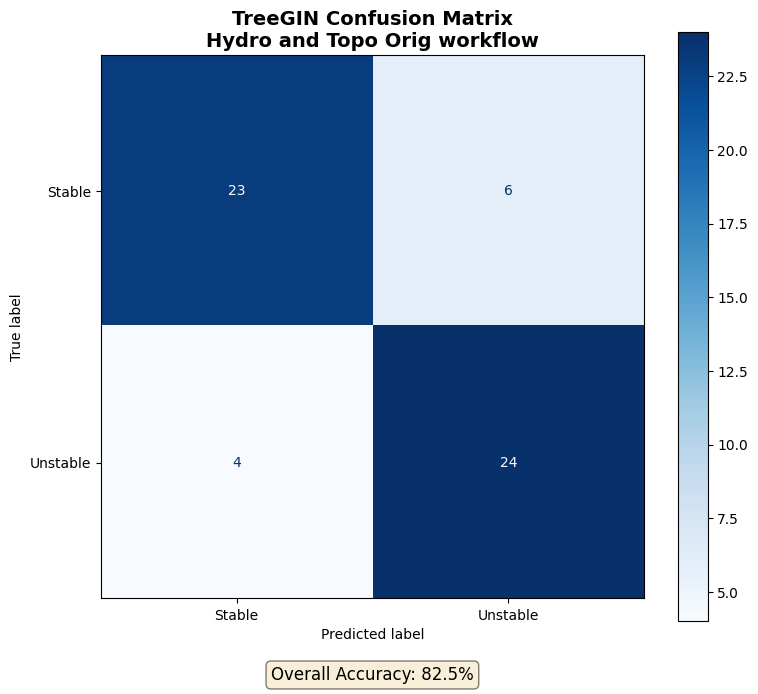


=== Per-Class Performance ===
Stable: 79.3% (23/29)
Unstable: 85.7% (24/28)


In [27]:
# Get predictions on test set
model.load_state_dict(best_model)
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        out = model(data)
        pred = out.argmax(dim=1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(data.y.cpu().numpy())

# Create confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Stable', 'Unstable'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('TreeGIN Confusion Matrix\nHydro and Topo Orig workflow', fontsize=14, fontweight='bold')

# Add accuracy to plot
acc = np.trace(cm) / np.sum(cm)
ax.text(0.5, -0.15, f'Overall Accuracy: {acc:.1%}', 
        transform=ax.transAxes, ha='center', fontsize=12,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('fig_564hydroTopoSUVL3_cm.png', dpi=300, bbox_inches='tight')
plt.show()

# Print per-class accuracy
print("\n=== Per-Class Performance ===")
for i, label in enumerate(['Stable', 'Unstable']):
    class_acc = cm[i, i] / cm[i, :].sum() if cm[i, :].sum() > 0 else 0
    print(f"{label}: {class_acc:.1%} ({cm[i, i]}/{cm[i, :].sum()})")